## setup

In [11]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import numpy as np
import copy
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, accuracy_score
import torch
import torch.nn as nn
import torch.nn.functional as F


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
import numpy as np
import torch

def evaluate(model, X, Y, params, batch_size=64):
    was_training = model.training
    model.eval()

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            e = min(s + batch_size, len(X))

            inputs = torch.from_numpy(X[s:e]).float()

            inputs = inputs.cuda(0)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())

    probs = np.concatenate(all_probs, axis=0)
    pred_labels = np.concatenate(all_preds, axis=0)


    results = []

    for param in params:
        if param == "acc":
            results.append(accuracy_score(Y, pred_labels))

        elif param == "auc":
            try:
                results.append(
                    roc_auc_score(
                        Y,
                        probs,
                        multi_class="ovo",
                        labels=np.arange(probs.shape[1])
                    )
                )
            except ValueError:
                results.append(None)

        elif param == "fmeasure":
            results.append(f1_score(Y, pred_labels, average="macro"))

    

    if was_training:
        model.train()
    else:
        model.eval()
    return results

In [13]:
import numpy as np
import torch
from mne.decoding import CSP


class CSPTimeSeriesExtractor:
    """
    Fits multiclass CSP on training epochs and applies the learned spatial
    filters while preserving the temporal dimension.

    Input:
        X: (trials, channels, samples)
           or (trials, 1, channels, samples)

    Output:
        X_csp: (trials, n_components, samples)
    """

    def __init__(
        self,
        n_components=8,
        reg="ledoit_wolf",
        cov_est="concat",
        norm_trace=False,
        component_order="mutual_info",
    ):
        self.n_components = n_components

        self.csp = CSP(
            n_components=n_components,
            reg=reg,
            log=None,
            cov_est=cov_est,
            norm_trace=norm_trace,
            component_order=component_order,
            transform_into="csp_space",
        )

        self.is_fitted = False

    @staticmethod
    def _prepare_input(X):
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()

        X = np.asarray(X, dtype=np.float64)

        if X.ndim == 4:
            if X.shape[1] != 1:
                raise ValueError(
                    "Four-dimensional input must have shape "
                    "(trials, 1, channels, samples)."
                )
            X = X[:, 0]

        if X.ndim != 3:
            raise ValueError(
                "Expected shape (trials, channels, samples) or "
                "(trials, 1, channels, samples)."
            )

        return X

    def fit(self, X_train, y_train):
        X_train = self._prepare_input(X_train)
        y_train = np.asarray(y_train)

        if len(X_train) != len(y_train):
            raise ValueError("X_train and y_train have different lengths.")

        self.csp.fit(X_train, y_train)
        self.is_fitted = True

        return self

    def transform(self, X):
        if not self.is_fitted:
            raise RuntimeError("Call fit() using training data first.")

        X = self._prepare_input(X)

        # With transform_into="csp_space", MNE returns:
        # trials x CSP components x samples
        X_csp = self.csp.transform(X)

        return np.asarray(X_csp, dtype=np.float32)

    def fit_transform(self, X_train, y_train):
        self.fit(X_train, y_train)
        return self.transform(X_train)

    def transform_tensor(self, X, device=None):
        X_csp = self.transform(X)

        # Add EEGNet's singleton input-channel dimension
        X_csp = torch.from_numpy(X_csp).unsqueeze(1)

        if device is not None:
            X_csp = X_csp.to(device)

        return X_csp

In [14]:


class EEGNetTorch(nn.Module):
    """
    Input:
        (batch, 1, Chans, Samples)

    When CSP is used:
        Chans = number of CSP components
    """

    def __init__(
        self,
        nb_classes=4,
        Chans=8,
        Samples=1001,
        dropoutRate=0.5,
        kernLength=125,
        F1=8,
        D=2,
        F2=16,
    ):
        super().__init__()

        self.conv_temporal = nn.Conv2d(
            in_channels=1,
            out_channels=F1,
            kernel_size=(1, kernLength),
            padding="same",
            bias=False,
        )

        self.bn1 = nn.BatchNorm2d(
            F1,
            eps=1e-3,
            momentum=0.01,
        )

        # Spatial convolution now spans all CSP components
        self.conv_spatial = nn.Conv2d(
            in_channels=F1,
            out_channels=F1 * D,
            kernel_size=(Chans, 1),
            groups=F1,
            bias=False,
        )

        self.bn2 = nn.BatchNorm2d(
            F1 * D,
            eps=1e-3,
            momentum=0.01,
        )

        self.pool1 = nn.AvgPool2d(
            kernel_size=(1, 4)
        )

        self.drop1 = nn.Dropout(dropoutRate)

        self.sepConv = nn.Conv2d(
            in_channels=F1 * D,
            out_channels=F1 * D,
            kernel_size=(1, 16),
            padding="same",
            groups=F1 * D,
            bias=False,
        )

        self.sep_pointwise = nn.Conv2d(
            in_channels=F1 * D,
            out_channels=F2,
            kernel_size=(1, 1),
            bias=False,
        )

        self.bn3 = nn.BatchNorm2d(
            F2,
            eps=1e-3,
            momentum=0.01,
        )

        self.pool2 = nn.AvgPool2d(
            kernel_size=(1, 8)
        )

        self.drop2 = nn.Dropout(dropoutRate)

        with torch.no_grad():
            dummy = torch.zeros(
                1,
                1,
                Chans,
                Samples,
            )

            features = self._features(dummy)
            self.flatten_dim = features.flatten(1).shape[1]

        self.classifier = nn.Linear(
            self.flatten_dim,
            nb_classes,
        )

    def _features(self, x):
        x = self.conv_temporal(x)
        x = self.bn1(x)

        x = self.conv_spatial(x)
        x = self.bn2(x)
        x = F.elu(x)

        x = self.pool1(x)
        x = self.drop1(x)

        x = self.sepConv(x)
        x = self.sep_pointwise(x)
        x = self.bn3(x)
        x = F.elu(x)

        x = self.pool2(x)
        x = self.drop2(x)

        return x

    def forward(self, x):
        x = self._features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)

## model

In [7]:

batch_size = 32
num_epochs = 100
k = 9

params = ["acc", "auc", "fmeasure"]

patience = 15
min_delta = 1e-4
fold_results = []

Raw EEG shape: (5184, 22, 1001)
Labels: ['feet' 'left_hand' 'right_hand' 'tongue']
Subjects: [1 2 3 4 5 6 7 8 9]

Fold 1/9 — held-out subject: S1
Before CSP:
  Training: (4608, 22, 1001)
  Validation: (576, 22, 1001)
Computing rank from data with rank=None
    Using tolerance 2.8e+02 (2.2e-16 eps * 22 dim * 5.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
After CSP:
  Training: (4608, 8, 1001)
  Validation: (576, 8, 1001)


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/torch/nn/modules/conv.py:560: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1090.)
  return F.conv2d(


Epoch 01/60 | train loss=1.3718 | held-out loss=1.3698
Epoch 02/60 | train loss=1.3278 | held-out loss=1.2953
Epoch 03/60 | train loss=1.2943 | held-out loss=1.2296
Epoch 04/60 | train loss=1.2490 | held-out loss=1.1822
Epoch 05/60 | train loss=1.1947 | held-out loss=1.1189
Epoch 06/60 | train loss=1.1482 | held-out loss=1.0836
Epoch 07/60 | train loss=1.1102 | held-out loss=1.0624
Epoch 08/60 | train loss=1.0901 | held-out loss=1.0049
Epoch 09/60 | train loss=1.0645 | held-out loss=1.0013
Epoch 10/60 | train loss=1.0483 | held-out loss=0.9919
Epoch 11/60 | train loss=1.0269 | held-out loss=0.9787
Epoch 12/60 | train loss=1.0254 | held-out loss=0.9558
Epoch 13/60 | train loss=1.0155 | held-out loss=0.9325
Epoch 14/60 | train loss=1.0152 | held-out loss=0.9906
Epoch 15/60 | train loss=0.9952 | held-out loss=0.9588
Epoch 16/60 | train loss=1.0014 | held-out loss=0.9529
Epoch 17/60 | train loss=0.9888 | held-out loss=0.9388
Epoch 18/60 | train loss=0.9975 | held-out loss=0.9904
Epoch 19/6

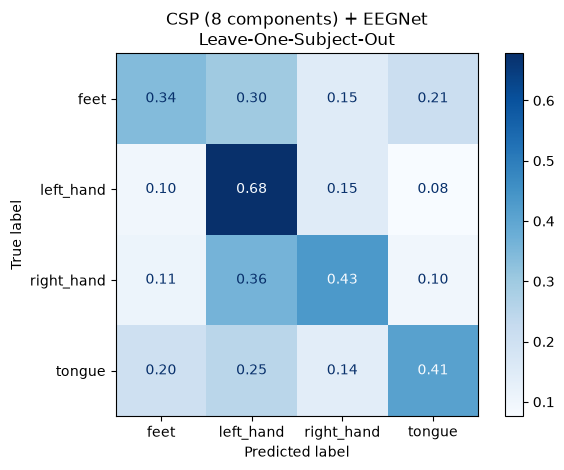

In [15]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch

from mne.decoding import CSP
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# Configuration
# ============================================================

batch_size = 32
num_epochs = 60

n_csp_components = 8

# These must already exist in your notebook:
# device
# params
# evaluate
# patience
# min_delta
# EEGNetTorch


# ============================================================
# Load all subjects
# ============================================================

X_list = []
y_list = []
subjects_list = []

for subject in range(1, 10):

    Xi = np.load(
        f"/home/hia2037/EEGMotorImagery-Classification/Data/X{subject}.npy"
    ).astype(np.float32)

    # Do not add the EEGNet singleton dimension yet.
    # CSP expects:
    # samples x channels x time
    if Xi.ndim != 3:
        raise ValueError(
            f"Subject {subject}: expected Xi with shape "
            f"(trials, channels, samples), got {Xi.shape}"
        )

    yi = np.load(
        f"/home/hia2037/EEGMotorImagery-Classification/Data/X{subject}L.npy"
    )

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(
        np.full(len(yi), subject, dtype=np.int64)
    )


X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

label_encoder = LabelEncoder()
y_cv = label_encoder.fit_transform(y).astype(np.int64)

X_cv = X.astype(np.float64)

print("Raw EEG shape:", X_cv.shape)
print("Labels:", label_encoder.classes_)
print("Subjects:", np.unique(subjects))


# ============================================================
# Leave-one-subject-out evaluation
# ============================================================

logo = LeaveOneGroupOut()

fold_results = []
fold_conf_mats = []
fold_csp_objects = []

n_folds = logo.get_n_splits(
    X_cv,
    y_cv,
    groups=subjects
)


for fold, (train_idx, valid_idx) in enumerate(
    logo.split(X_cv, y_cv, groups=subjects),
    start=1,
):

    test_subject = int(np.unique(subjects[valid_idx])[0])

    print(
        f"\n{'=' * 70}\n"
        f"Fold {fold}/{n_folds} — held-out subject: S{test_subject}"
    )

    X_tr_raw = X_cv[train_idx]
    X_va_raw = X_cv[valid_idx]

    y_tr = y_cv[train_idx]
    y_va = y_cv[valid_idx]

    print("Before CSP:")
    print("  Training:", X_tr_raw.shape)
    print("  Validation:", X_va_raw.shape)

    # ========================================================
    # Fit CSP only on the training subjects
    # ========================================================

    csp = CSP(
        n_components=n_csp_components,
        reg="ledoit_wolf",
        log=None,
        cov_est="concat",
        transform_into="csp_space",
        norm_trace=False,
        component_order="mutual_info",
    )

    X_tr_csp = csp.fit_transform(
        X_tr_raw,
        y_tr,
    )

    X_va_csp = csp.transform(
        X_va_raw,
    )

    # MNE returns:
    # trials x CSP components x time
    print("After CSP:")
    print("  Training:", X_tr_csp.shape)
    print("  Validation:", X_va_csp.shape)

    # Add EEGNet input-channel dimension:
    # trials x 1 x CSP components x time
    X_tr = X_tr_csp[:, None, :, :].astype(np.float32)
    X_va = X_va_csp[:, None, :, :].astype(np.float32)

    # Saving the object is optional, but useful for plotting filters later.
    fold_csp_objects.append({
        "subject": test_subject,
        "csp": csp,
    })

    # ========================================================
    # DataLoaders
    # ========================================================

    train_ds = TensorDataset(
        torch.from_numpy(X_tr),
        torch.from_numpy(y_tr).long(),
    )

    valid_ds = TensorDataset(
        torch.from_numpy(X_va),
        torch.from_numpy(y_va).long(),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=torch.cuda.is_available(),
    )

    valid_loader = DataLoader(
        valid_ds,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=torch.cuda.is_available(),
    )

    # ========================================================
    # EEGNet
    # ========================================================

    net = EEGNetTorch(
        nb_classes=4,
        Chans=n_csp_components,
        Samples=X_tr.shape[-1],
        kernLength=64,
        F1=32,
        D=4,
        F2=16,
        dropoutRate=0.4854763234903182,
    ).to(device)

    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=0.0004102432506048275,
    )

    criterion = torch.nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = None
    epochs_without_improvement = 0

    # ========================================================
    # Training
    # ========================================================

    for epoch in range(num_epochs):

        net.train()

        running_loss = 0.0
        n_seen = 0

        for inputs, labels in train_loader:

            inputs = inputs.to(
                device,
                non_blocking=True,
            )

            labels = labels.to(
                device,
                non_blocking=True,
            )

            optimizer.zero_grad(set_to_none=True)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            n_seen += inputs.size(0)

        train_loss = running_loss / max(n_seen, 1)

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        net.eval()

        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():

            for inputs, labels in valid_loader:

                inputs = inputs.to(
                    device,
                    non_blocking=True,
                )

                labels = labels.to(
                    device,
                    non_blocking=True,
                )

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_seen += inputs.size(0)

        val_loss = val_loss / max(val_seen, 1)

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train loss={train_loss:.4f} | "
            f"held-out loss={val_loss:.4f}"
        )

        if val_loss < best_val_loss - min_delta:

            best_val_loss = val_loss
            best_model_state = copy.deepcopy(
                net.state_dict()
            )

            best_epoch = epoch + 1
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}; "
                f"best epoch={best_epoch}"
            )
            break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    # ========================================================
    # Evaluation
    # ========================================================

    metrics = dict(
        zip(
            params,
            evaluate(
                net,
                X_va,
                y_va,
                params,
            ),
        )
    )

    metrics["subject"] = test_subject
    metrics["best_epoch"] = best_epoch

    fold_results.append(metrics)

    net.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():

        for inputs, labels in valid_loader:

            inputs = inputs.to(
                device,
                non_blocking=True,
            )

            outputs = net(inputs)

            predictions = torch.argmax(
                outputs,
                dim=1,
            )

            all_predictions.append(
                predictions.cpu().numpy()
            )

            all_targets.append(
                labels.numpy()
            )

    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_targets)

    # Raw confusion counts
    cm_counts = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
    )

    # Row-normalized confusion matrix
    cm_normalized = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2, 3],
        normalize="true",
    )

    fold_conf_mats.append(cm_normalized)

    print("\nConfusion matrix counts:")
    print(cm_counts)

    print("\nNormalized confusion matrix:")
    print(np.round(cm_normalized, 3))

    print(
        f"\nFold {fold} final metrics "
        f"for S{test_subject}:"
    )

    print(metrics)


# ============================================================
# Aggregate cross-subject results
# ============================================================

print("\n========== Cross-Validation Results ==========")

avg_metrics = {}

for metric in params:

    values = [
        result[metric]
        for result in fold_results
    ]

    avg_metrics[metric] = {
        "mean": float(np.mean(values)),
        "std": float(np.std(values)),
    }

    print(
        f"{metric}: "
        f"{np.mean(values):.4f} ± "
        f"{np.std(values):.4f}"
    )


avg_cm = np.mean(
    np.stack(fold_conf_mats, axis=0),
    axis=0,
)

print("\nAverage normalized confusion matrix:")
print(np.round(avg_cm, 3))


disp = ConfusionMatrixDisplay(
    confusion_matrix=avg_cm,
    display_labels=label_encoder.classes_,
)

disp.plot(
    cmap="Blues",
    values_format=".2f",
)

plt.title(
    f"CSP ({n_csp_components} components) + EEGNet\n"
    "Leave-One-Subject-Out"
)

plt.tight_layout()
plt.show()

## csp tweaking

In [17]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from mne.decoding import CSP
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# Configuration
# ============================================================

CSP_COMPONENT_OPTIONS = [4, 6, 8, 12, 16]

batch_size = 32
num_epochs = 60

# Must already be defined:
# EEGNetTorch
# evaluate
# device
# params
# patience
# min_delta


# ============================================================
# Load data
# ============================================================

X_list = []
y_list = []
subjects_list = []

for subject in range(1, 10):

    Xi = np.load(
        f"/home/hia2037/EEGMotorImagery-Classification/Data/X{subject}.npy"
    ).astype(np.float32)

    yi = np.load(
        f"/home/hia2037/EEGMotorImagery-Classification/Data/X{subject}L.npy"
    )

    # CSP expects:
    # trials x channels x samples
    if Xi.ndim == 4 and Xi.shape[1] == 1:
        Xi = Xi[:, 0]

    if Xi.ndim != 3:
        raise ValueError(
            f"S{subject}: expected (trials, channels, samples), "
            f"got {Xi.shape}"
        )

    X_list.append(Xi)
    y_list.append(yi)

    subjects_list.append(
        np.full(len(yi), subject, dtype=np.int64)
    )


X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
subjects = np.concatenate(subjects_list, axis=0)

label_encoder = LabelEncoder()
y_cv = label_encoder.fit_transform(y).astype(np.int64)

# MNE covariance calculations are more stable in float64
X_cv = X.astype(np.float64)

print("EEG shape:", X_cv.shape)
print("Classes:", label_encoder.classes_)
print("Subjects:", np.unique(subjects))


# ============================================================
# Run one CSP-component configuration
# ============================================================

def run_csp_eegnet(n_csp_components):

    logo = LeaveOneGroupOut()

    fold_results = []
    fold_confusion_matrices = []

    n_folds = logo.get_n_splits(
        X_cv,
        y_cv,
        groups=subjects
    )

    for fold, (train_idx, valid_idx) in enumerate(
        logo.split(X_cv, y_cv, groups=subjects),
        start=1
    ):

        held_out_subject = int(
            np.unique(subjects[valid_idx])[0]
        )

        print(
            f"\nCSP={n_csp_components} | "
            f"Fold {fold}/{n_folds} | "
            f"Held-out subject S{held_out_subject}"
        )

        X_train_raw = X_cv[train_idx]
        X_valid_raw = X_cv[valid_idx]

        y_train = y_cv[train_idx]
        y_valid = y_cv[valid_idx]

        # ----------------------------------------------------
        # Fit MNE CSP only on training subjects
        # ----------------------------------------------------

        csp = CSP(
            n_components=n_csp_components,
            reg="ledoit_wolf",
            log=None,
            cov_est="concat",
            transform_into="csp_space",
            norm_trace=False,
            component_order="mutual_info",
        )

        X_train_csp = csp.fit_transform(
            X_train_raw,
            y_train
        )

        X_valid_csp = csp.transform(
            X_valid_raw
        )

        print(
            "CSP shapes:",
            X_train_csp.shape,
            X_valid_csp.shape
        )

        print("Full CSP filter matrix:", csp.filters_.shape)
        print("Full CSP pattern matrix:", csp.patterns_.shape)

        # EEGNet requires:
        # batch x 1 x CSP-components x samples
        X_train = X_train_csp[:, None, :, :].astype(
            np.float32
        )

        X_valid = X_valid_csp[:, None, :, :].astype(
            np.float32
        )

        train_dataset = TensorDataset(
            torch.from_numpy(X_train),
            torch.from_numpy(y_train).long()
        )

        valid_dataset = TensorDataset(
            torch.from_numpy(X_valid),
            torch.from_numpy(y_valid).long()
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            pin_memory=torch.cuda.is_available()
        )

        valid_loader = DataLoader(
            valid_dataset,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=torch.cuda.is_available()
        )

        # ----------------------------------------------------
        # Model
        # ----------------------------------------------------

        net = EEGNetTorch(
            nb_classes=4,
            Chans=n_csp_components,
            Samples=X_train.shape[-1],
            kernLength=64,
            F1=32,
            D=4,
            F2=16,
            dropoutRate=0.4854763234903182,
        ).to(device)

        optimizer = torch.optim.Adam(
            net.parameters(),
            lr=0.0004102432506048275
        )

        criterion = torch.nn.CrossEntropyLoss()

        best_val_loss = float("inf")
        best_model_state = None
        best_epoch = None
        epochs_without_improvement = 0

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        for epoch in range(num_epochs):

            net.train()

            train_loss_sum = 0.0
            train_count = 0

            for inputs, labels in train_loader:

                inputs = inputs.to(
                    device,
                    non_blocking=True
                )

                labels = labels.to(
                    device,
                    non_blocking=True
                )

                optimizer.zero_grad(set_to_none=True)

                outputs = net(inputs)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                train_loss_sum += (
                    loss.item() * inputs.size(0)
                )

                train_count += inputs.size(0)

            train_loss = (
                train_loss_sum / max(train_count, 1)
            )

            net.eval()

            valid_loss_sum = 0.0
            valid_count = 0

            with torch.no_grad():

                for inputs, labels in valid_loader:

                    inputs = inputs.to(
                        device,
                        non_blocking=True
                    )

                    labels = labels.to(
                        device,
                        non_blocking=True
                    )

                    outputs = net(inputs)
                    loss = criterion(outputs, labels)

                    valid_loss_sum += (
                        loss.item() * inputs.size(0)
                    )

                    valid_count += inputs.size(0)

            valid_loss = (
                valid_loss_sum / max(valid_count, 1)
            )

            if valid_loss < best_val_loss - min_delta:

                best_val_loss = valid_loss

                best_model_state = copy.deepcopy(
                    net.state_dict()
                )

                best_epoch = epoch + 1
                epochs_without_improvement = 0

            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                break

        if best_model_state is not None:
            net.load_state_dict(best_model_state)

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        metric_values = evaluate(
            net,
            X_valid,
            y_valid,
            params
        )

        metrics = dict(zip(params, metric_values))

        metrics["subject"] = held_out_subject
        metrics["n_csp_components"] = n_csp_components
        metrics["best_epoch"] = best_epoch

        fold_results.append(metrics)

        # ----------------------------------------------------
        # Predictions and confusion matrix
        # ----------------------------------------------------

        predictions = []
        targets = []

        net.eval()

        with torch.no_grad():

            for inputs, labels in valid_loader:

                inputs = inputs.to(
                    device,
                    non_blocking=True
                )

                outputs = net(inputs)

                predicted_labels = torch.argmax(
                    outputs,
                    dim=1
                )

                predictions.append(
                    predicted_labels.cpu().numpy()
                )

                targets.append(labels.numpy())

        y_pred = np.concatenate(predictions)
        y_true = np.concatenate(targets)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1, 2, 3],
            normalize="true"
        )

        fold_confusion_matrices.append(cm)

        print(
            f"S{held_out_subject} | "
            f"acc={metrics['acc']:.4f} | "
            f"best epoch={best_epoch}"
        )

    results_df = pd.DataFrame(fold_results)

    average_cm = np.mean(
        np.stack(fold_confusion_matrices),
        axis=0
    )

    return results_df, average_cm


# ============================================================
# Run all CSP component counts
# ============================================================

all_results = []
average_confusion_matrices = {}

for n_components in CSP_COMPONENT_OPTIONS:

    results_df, average_cm = run_csp_eegnet(
        n_components
    )

    all_results.append(results_df)

    average_confusion_matrices[n_components] = average_cm


all_results_df = pd.concat(
    all_results,
    ignore_index=True
)

all_results_df.to_csv(
    "csp_component_comparison.csv",
    index=False
)

print("\nAll results:")
print(all_results_df.round(4))

EEG shape: (5184, 22, 1001)
Classes: ['feet' 'left_hand' 'right_hand' 'tongue']
Subjects: [1 2 3 4 5 6 7 8 9]

CSP=4 | Fold 1/9 | Held-out subject S1
Computing rank from data with rank=None
    Using tolerance 2.8e+02 (2.2e-16 eps * 22 dim * 5.8e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
CSP shapes: (4608, 4, 1001) (576, 4, 1001)
Full CSP filter matrix: (22, 22)
Full CSP pattern matrix: (22, 22)
S1 | acc=0.6337 | best epoch=17

CSP=4 | Fold 2/9 | Held-out subject S2
Computing rank from data with rank=None
    Using tolerance 2.7e+02 (2.2e-16 eps * 22 dim * 5.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels w

   n_csp_components    mean     std
0                 4  0.4406  0.1531
1                 6  0.4645  0.1808
2                 8  0.4576  0.1656
3                12  0.4660  0.1763
4                16  0.4392  0.1705


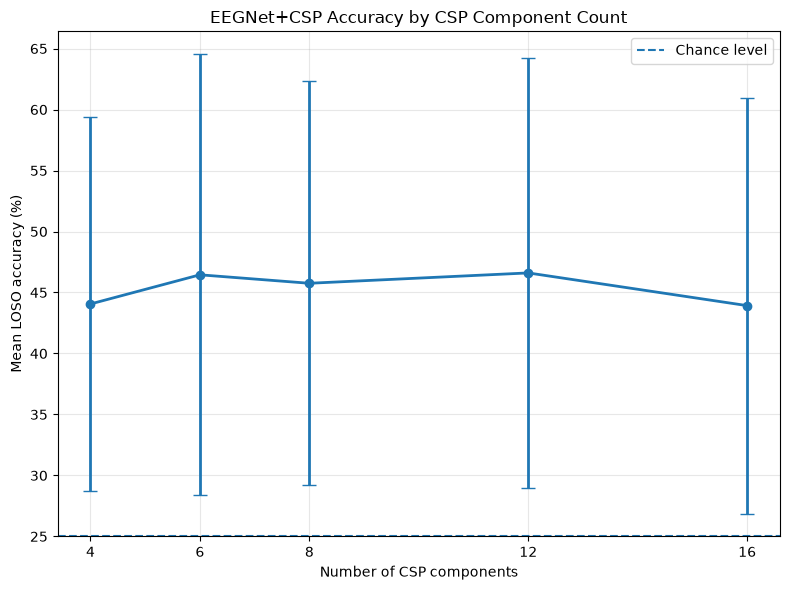

In [18]:
summary_df = (
    all_results_df
    .groupby("n_csp_components")["acc"]
    .agg(["mean", "std"])
    .reset_index()
)

print(summary_df.round(4))

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(
    summary_df["n_csp_components"],
    summary_df["mean"] * 100,
    yerr=summary_df["std"] * 100,
    marker="o",
    capsize=5,
    linewidth=2
)

ax.axhline(
    25,
    linestyle="--",
    linewidth=1.5,
    label="Chance level"
)

ax.set_xticks(CSP_COMPONENT_OPTIONS)
ax.set_xlabel("Number of CSP components")
ax.set_ylabel("Mean LOSO accuracy (%)")
ax.set_title("EEGNet+CSP Accuracy by CSP Component Count")
ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

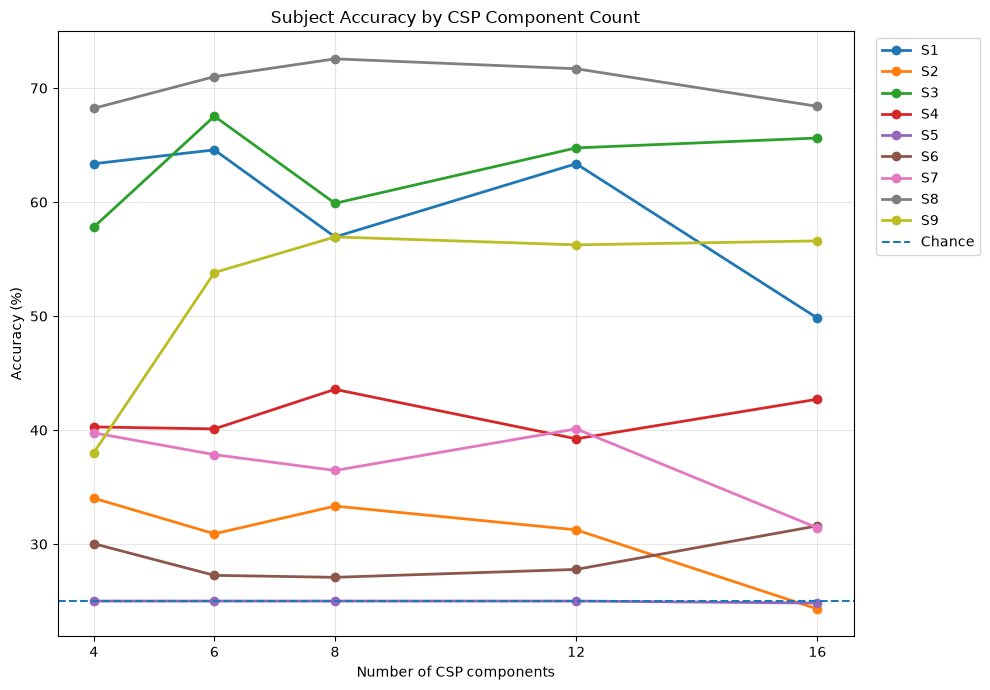

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

for subject in range(1, 10):

    subject_df = (
        all_results_df[
            all_results_df["subject"] == subject
        ]
        .sort_values("n_csp_components")
    )

    ax.plot(
        subject_df["n_csp_components"],
        subject_df["acc"] * 100,
        marker="o",
        linewidth=2,
        label=f"S{subject}"
    )

ax.axhline(
    25,
    linestyle="--",
    linewidth=1.5,
    label="Chance"
)

ax.set_xticks(CSP_COMPONENT_OPTIONS)
ax.set_xlabel("Number of CSP components")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Subject Accuracy by CSP Component Count")
ax.grid(alpha=0.3)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

fig.tight_layout()
plt.show()